In [20]:
from dft_ab import run_dft_ab
from gpaw import restart
from gpaw.new.ase_interface import ASECalculator
import ase
from extract_pi_dft_bands import save_pi_dft_bands, load_pi_dft_bands

In [21]:
filename = 'ab.gpw'
filepath = '../gpw/' + filename


In [4]:
run_dft_ab(filename)

Total energy: -36.857529 eV
File saved to ../ab.gpw


## DFT

In [22]:
atoms, calc = restart(filepath)
atoms: ase.atoms.Atoms # for hints
calc: ASECalculator

In [80]:
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'])

[[ 1.27707018 -0.73731681  0.        ]
 [ 1.25046456 -0.78339912  0.        ]
 [ 1.22385893 -0.82948142  0.        ]
 [ 1.1972533  -0.87556372  0.        ]
 [ 1.17064767 -0.92164602  0.        ]
 [ 1.14404204 -0.96772832  0.        ]
 [ 1.11743641 -1.01381062  0.        ]
 [ 1.09083078 -1.05989292  0.        ]
 [ 1.06422515 -1.10597522  0.        ]
 [ 1.03761952 -1.15205752  0.        ]
 [ 1.0110139  -1.19813982  0.        ]
 [ 0.98440827 -1.24422212  0.        ]
 [ 0.95780264 -1.29030443  0.        ]
 [ 0.93119701 -1.33638673  0.        ]
 [ 0.90459138 -1.38246903  0.        ]
 [ 0.87798575 -1.42855133  0.        ]
 [ 0.85138012 -1.47463363  0.        ]
 [ 0.82558073 -1.42994776  0.        ]
 [ 0.79978133 -1.38526189  0.        ]
 [ 0.77398193 -1.34057603  0.        ]
 [ 0.74818253 -1.29589016  0.        ]
 [ 0.72238313 -1.25120429  0.        ]
 [ 0.69658374 -1.20651842  0.        ]
 [ 0.67078434 -1.16183256  0.        ]
 [ 0.64498494 -1.11714669  0.        ]
 [ 0.61918554 -1.07246082

In [23]:
kpts, E_pi, band_indices, EF = load_pi_dft_bands()

In [24]:
EF

array(-2.19881375)

## TB

In [25]:
from tb_bands import TBBandManager
import numpy as np
theta0 = np.array([
            3.1,  # gamma0
            0.39,  # gamma1
            0.315,  # gamma3
            0.044,  # gamma4
            0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
        ])
manager = TBBandManager(atoms)

manager.create_3d_plot(theta0)


File saved in ../data/3d_bands.html


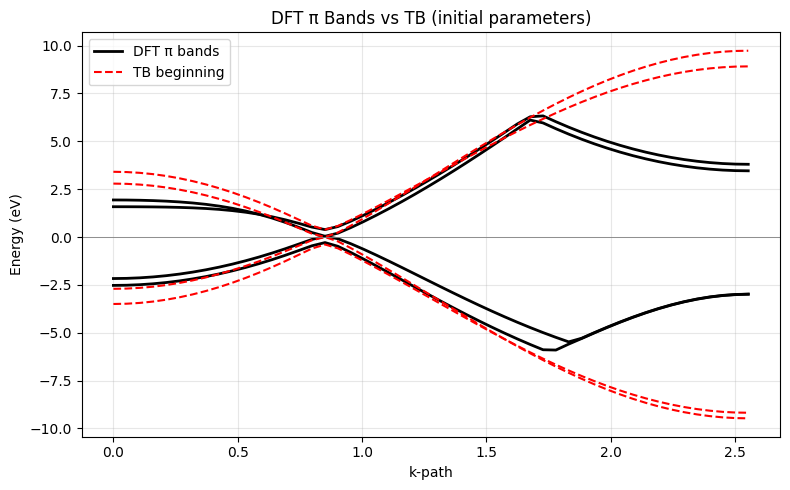

In [26]:
from bandplot import plot_bands

# Compute TB bands:
E_tb_0 = manager.tb_bands(kpts, theta0)

# Number of bands in the DFT π set
nb = E_pi.shape[1]

bands = {
    "DFT π bands": {
        "E": E_pi,         # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    },
    "TB beginning": {
        "E": E_tb_0[:, :nb],   # match π bands only
        "color": "r",
        "ls": "--",
        "lw": 1.5,
    }
}

plot_bands(kpts, bands,
           title="DFT π Bands vs TB (initial parameters)")


In [27]:
from tb_parameters_optimizer import optimize
E_pi_ordered = E_pi[:, [2, 0, 1, 3]] # IMPORTANT! Must reorder bands so that they match from the two models.

theta_fit = optimize(manager, theta0, kpts, E_pi_ordered, 0.5, 1.5)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.2031e+00                                    1.44e+01    
       1              3         1.0135e+00      3.19e+00       7.85e-01       2.31e+00    
       2              4         6.4089e-01      3.73e-01       3.81e-01       5.62e-01    
       3              5         6.3817e-01      2.72e-03       1.91e-01       4.89e-01    
       4              6         6.1831e-01      1.99e-02       4.79e-02       1.79e-01    
       5              7         6.1120e-01      7.11e-03       9.57e-02       7.07e-02    
       6              9         6.1041e-01      7.91e-04       1.51e-02       1.40e-02    
       7             11         6.1034e-01      7.56e-05       5.65e-03       4.02e-03    
       8             13         6.1032e-01      1.11e-05       2.02e-03       2.07e-03    
       9             14         6.1032e-01      1.20e-06       3.65e-03       3.08e-03    

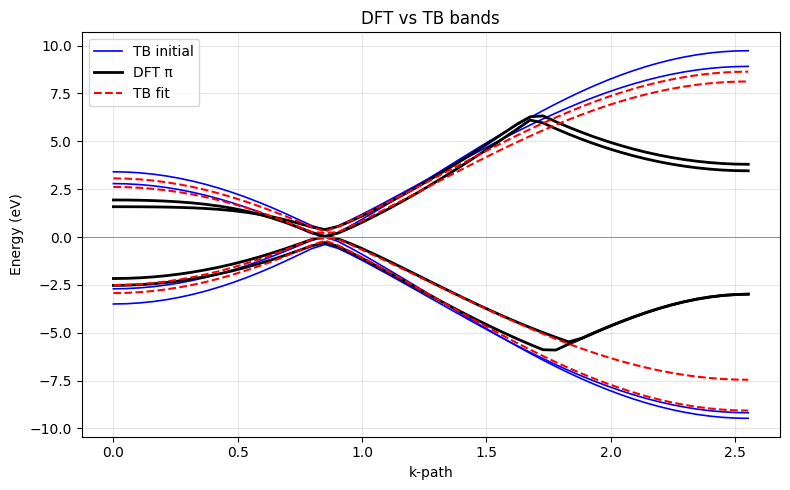

In [28]:
import matplotlib.pyplot as plt
import numpy as np

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)
E_tb_fit = manager.tb_bands(kpts, theta_fit)


from bandplot import plot_bands

bands = {
    "TB initial": {
        "E": E_tb_0,
        "color": "b",
        "ls": "-",
        "lw": 1.2
    },
    "DFT π": {
        "E": E_pi,
        "color": "k",
        "ls": "-",
        "lw": 2
    },
    "TB fit": {
        "E": E_tb_fit,
        "color": "r",
        "ls": "--",
        "lw": 1.5
    }
}

plot_bands(kpts, bands, title="DFT vs TB bands")


## Zoom in
Now we want to zoom in to see the result. We need to rer

In [29]:
from ase.dft.kpoints import get_bandpath, kpoint_convert

path = ['M', 'K', 'G']
bp = get_bandpath(path, atoms.cell)

k_point = bp.special_points['K']
k_point

array([ 0.33333333, -0.33333333,  0.        ])

In [88]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
%reload_ext autoreload

In [61]:
from extract_pi_dft_bands import save_pi_dft_bands
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'], npoints=200, zoom_label='K', zoom_distance=0.5)

Going to get distance 0.5 around K
Current kpath [[ 0.38131313 -0.23737374  0.        ]
 [ 0.37878788 -0.24242424  0.        ]
 [ 0.37626263 -0.24747475  0.        ]
 [ 0.37373737 -0.25252525  0.        ]
 [ 0.37121212 -0.25757576  0.        ]
 [ 0.36868687 -0.26262626  0.        ]
 [ 0.36616162 -0.26767677  0.        ]
 [ 0.36363636 -0.27272727  0.        ]
 [ 0.36111111 -0.27777778  0.        ]
 [ 0.35858586 -0.28282828  0.        ]
 [ 0.35606061 -0.28787879  0.        ]
 [ 0.35353535 -0.29292929  0.        ]
 [ 0.3510101  -0.2979798   0.        ]
 [ 0.34848485 -0.3030303   0.        ]
 [ 0.3459596  -0.30808081  0.        ]
 [ 0.34343434 -0.31313131  0.        ]
 [ 0.34090909 -0.31818182  0.        ]
 [ 0.33838384 -0.32323232  0.        ]
 [ 0.33585859 -0.32828283  0.        ]
 [ 0.33333333 -0.33333333  0.        ]
 [ 0.33082707 -0.33082707  0.        ]
 [ 0.3283208  -0.3283208   0.        ]
 [ 0.32581454 -0.32581454  0.        ]
 [ 0.32330827 -0.32330827  0.        ]
 [ 0.32080201 -

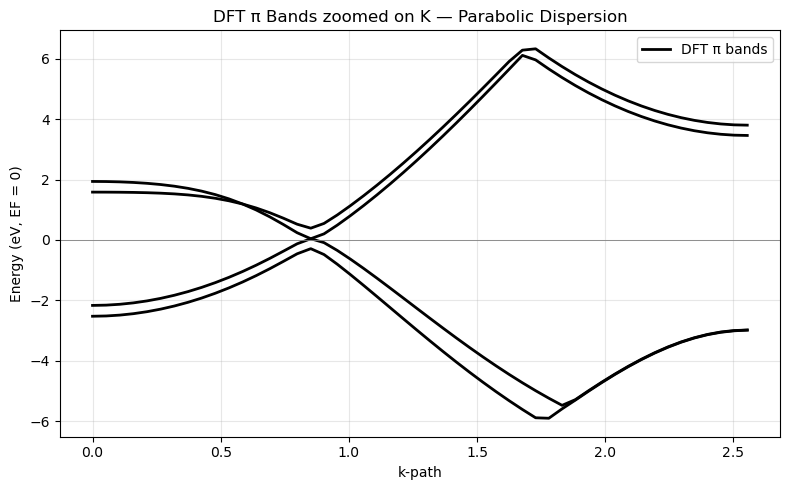

In [97]:
from bandplot import plot_bands

# Load the zoomed bands
kpts_zoom, band_energies_zoom, band_indices_zoom, EF_zoom = load_pi_dft_bands()

# Number of π bands in zoom region
nb = band_energies_zoom.shape[1]

# Build dataset dictionary
bands = {
    "DFT π bands": {
        "E": band_energies_zoom,   # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    }
}

# Plot
plot_bands(
    kpts_zoom,
    bands,
    title="DFT π Bands zoomed on K — Parabolic Dispersion",
    ylabel="Energy (eV, EF = 0)"
)


Notice the parabolic curve, which is correct.

## DFT DOS


In [91]:
import matplotlib.pyplot as plt
import numpy as np

In [92]:
e, dos = calc.get_dos(spin=0, npts=2001, width=0.2)

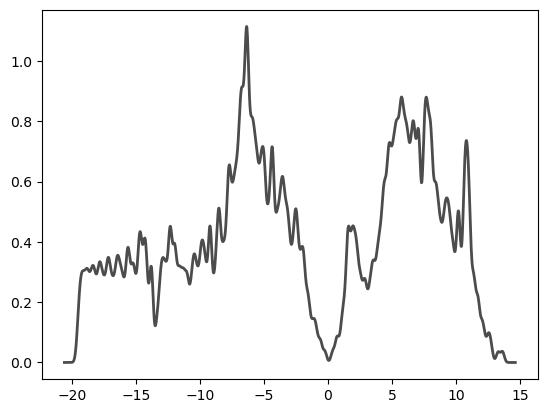

In [93]:
plt.plot(e - EF, dos, label='Total', c='k', lw=2, alpha=0.7)

In [94]:
dist = abs(E_pi.mean(axis=0) - EF)
idx_pi = np.argsort(dist)[:4]   # 4 π bands in bilayer
print("π-band indices:", idx_pi)


π-band indices: [0 2 1 3]


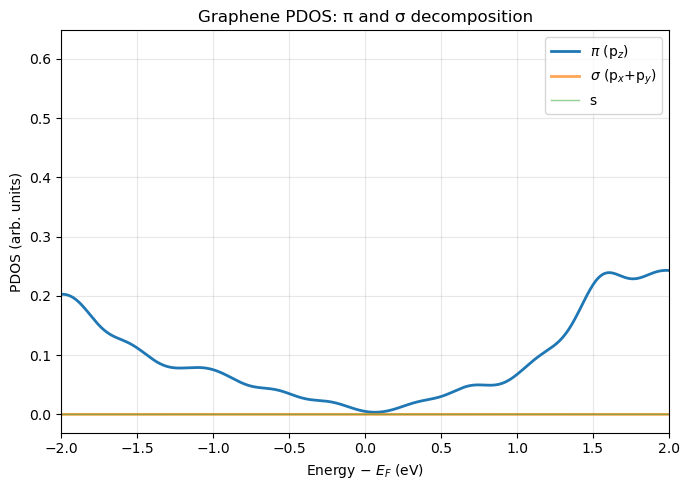

Saved interactive PDOS to: ../data/graphene_pdos_interactive.html


In [96]:
from pdos_plotter import plot_pdos_pi_sigma
import importlib
import pdos_plotter

importlib.reload(pdos_plotter)
# assuming you already have:
# atoms, calc = restart('yourfile.gpw')
plot_pdos_pi_sigma(calc, atoms, atom_indices=[0,1,2,3,], zoom=(-2, 2), save_html=True)

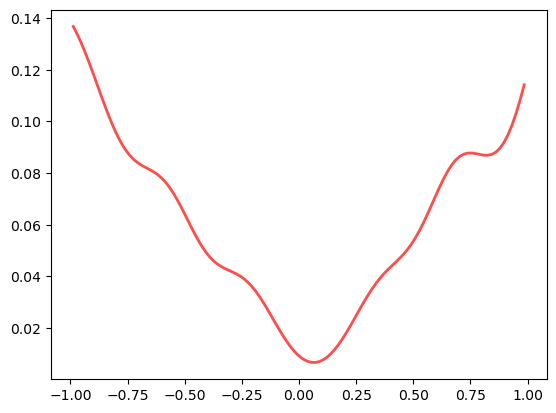

In [14]:
e_min_EF = e - EF
filter = (e_min_EF > -1) & (e_min_EF < 1)
plt.plot(e_min_EF[filter], dos[filter], label='Band', c='r', lw=2, alpha=0.7)

In [19]:
print(f'The minimum value reached by the DOS is {dos[filter].min()} at k={dos[filter].argmin()}')

NameError: name 'dos' is not defined

## Trigonal warping

In [55]:
import importlib
import trigonal_warping

importlib.reload(trigonal_warping)   # reloads the module
from gpaw import restart
from trigonal_warping import (
    compute_patch_bands,
    find_pi_bands,
    plot_trigonal_warping,
    plot_trigonal_warping_3d,
make_k_patch_around_K
)

In [4]:
# Load your converged bilayer AB calc
atoms, calc = restart("../gpw/ab.gpw")
Nq=11
# 1) Compute dense patch around K
qx, qy, E_shifted, EF = compute_patch_bands(
    calc,
    atoms,
    radius=0.012,   # try 0.03, then maybe smaller like 0.015
    Nq=Nq,         # 41–81 is reasonable
    #nbands=None,  # or explicitly if needed
    txt="tw_blg_patch.txt"
)


going to generate bandpath
generated bandpath
Starting to compute the energies...


the closest energies to 0 are [7 8 6 9], [[[-0.03860201  0.1391978  -0.38806254  0.46672412]
  [-0.03515674  0.13319102 -0.37158463  0.45311508]
  [-0.03439717  0.13101112 -0.36286014  0.44596616]
  [-0.03439717  0.13101112 -0.36286013  0.44596616]
  [-0.03515674  0.13319101 -0.37158462  0.45311507]
  [-0.038602    0.13919779 -0.38806253  0.4667241 ]
  [-0.04703125  0.15094313 -0.41081505  0.48570226]
  [-0.06143956  0.16908469 -0.43835676  0.50889902]
  [-0.08131037  0.19287806 -0.46945555  0.53531274]
  [-0.10548729  0.22102846 -0.50318224  0.564154  ]
  [-0.132857    0.25234357 -0.53886432  0.59483061]]

 [[-0.02021491  0.11903834 -0.37792918  0.45891745]
  [-0.01381113  0.10921168 -0.35717564  0.44200328]
  [-0.01243295  0.10544983 -0.34368695  0.4311475 ]
  [-0.01254406  0.10469581 -0.33898214  0.42739102]
  [-0.01243295  0.10544983 -0.34368694  0.43114749]
  [-0.01381112  0.10921168 -0.35717563  0.44200326]
  [-0.0202149   0.11903832 -0.37792916  0.45891742]
  [-0.03361579  0.136

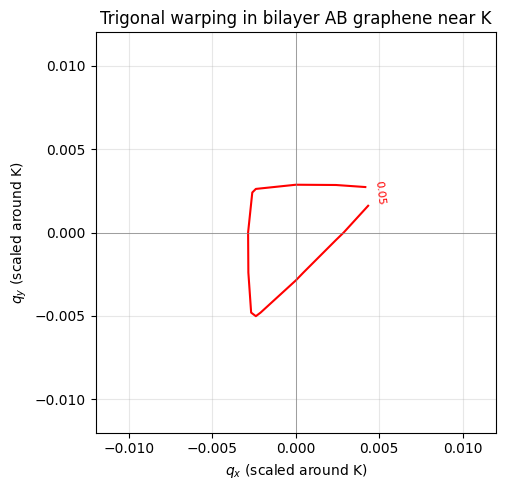

In [5]:
# 2) Select the lowest-energy conduction band (or two bands closest to EF)
#idx, E_low = select_low_energy_bands(E_shifted, n_bands=16)
#print("Low-energy band indices near EF:", idx)
#BE_low = E_shifted[:4]
import numpy as np
idx_pi, E_pi = find_pi_bands(E_shifted, n=4)

print("π-band indices (closest to EF):", idx_pi)


avg_pi = E_pi.mean(axis=(0,1))

# select entries > 0 (conduction)
pos = np.where(avg_pi > 0)[0]

if len(pos) == 0:
    raise RuntimeError("No positive-energy π conduction band found!")

# choose the conduction π band closest to zero
cond_idx_local = pos[np.argmin(avg_pi[pos])]

E_cond = E_pi[..., cond_idx_local]
print("Using conduction π band:", idx_pi[cond_idx_local])

# 3) Plot iso-energy contours at ±10 meV
plot_trigonal_warping(
    qx, qy, E_cond,
    E_iso=0.05,   # 10 meV in eV units
    title="Trigonal warping in bilayer AB graphene near K"
)

In [6]:
ix0, iy0 = E_cond.shape[0] // 2, E_cond.shape[1] // 2
print("E_cond at K (center) =", E_cond[ix0, iy0], "eV")


E_cond at K (center) = 0.04061874900487039 eV


In [8]:
# at K
E_center = E_shifted[Nq//2, Nq//2, :]
eps = np.abs(E_center)

# find the (positive) π band: smallest positive energy
candidates = np.where(E_center > 0)[0]
cond_idx = candidates[np.argmin(E_center[candidates])]


In [9]:
E_cond = E_shifted[..., cond_idx]


In [40]:
E_shifted.shape

(11, 11, 14)

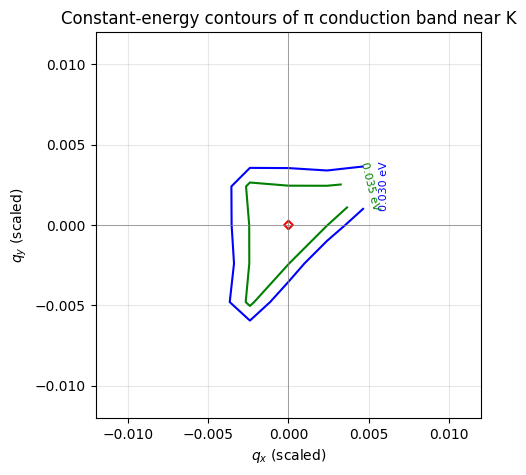

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# E_cond: (Nq, Nq) conduction π band, shifted so EF=0
# qx, qy: (Nq, Nq) mesh (scaled around K)

plt.figure(figsize=(5, 5))

# choose a few low energies in eV
levels = [0.03, 0.035, 0.04]
cs = plt.contour(qx, qy, E_cond, levels=levels, colors=['b', 'g', 'r'])
plt.clabel(cs, inline=True, fontsize=8, fmt="%.3f eV")

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal', 'box')

plt.xlabel(r"$q_x$ (scaled)")
plt.ylabel(r"$q_y$ (scaled)")
plt.title("Constant-energy contours of π conduction band near K")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [178]:
plot_trigonal_warping_3d(
    qx,
    qy,
    E_cond,
    #E_shifted[:, :, 8],
    #E_pi[:, :, 1],
   # title=f"Trigonal warping near K (band {idx[0]})",
    zlim=(0.03, 0.04),  # in eV
    save_html=True,
    html_path="../data/trigonal_warping_3d.html",
)

Saved interactive 3D trigonal-warping plot to: ../data/trigonal_warping_3d.html


In [195]:
from ase.dft.kpoints import kpoint_convert
kpts_patch, qx, qy = make_k_patch_around_K(atoms, radius=0.05, Nq=100)

k_point = kpoint_convert(atoms.cell, skpts_kc=bp.special_points['K'])
k_point_x, k_point_y = k_point[0], k_point[1]
qx, qy = qx + k_point_x, qy + k_point_y

Nq = qx.shape[0]

kpts_flat = np.column_stack([qx.ravel(), qy.ravel()])
from ase.dft.kpoints import get_bandpath, BandPath
bp: BandPath = get_bandpath(['G', 'K', 'M'], atoms.cell)


theta_2 = theta_fit
theta_2[2] = 0.1#0.35 # update gamma3
E_tb_flat = manager.tb_bands(kpts_flat, theta_2)
E_tb_grid = E_tb_flat.reshape(Nq, Nq, 4)

going to generate bandpath
generated bandpath


In [196]:
E_tb_0, E_tb_1 = E_tb_grid[:, :, 0], E_tb_grid[:, :, 1]
E_max = np.maximum(E_tb_0, E_tb_1)   # shape (Nq, Nq)

In [200]:
E_center = E_tb_grid[Nq // 2, Nq // 2, :]
eps = np.abs(E_center)

# find the (positive) π band: smallest positive energy
# candidates = np.where(E_center > 0)[0]
# cond_idx = candidates[np.argmin(E_center[candidates])]
#
# E_tb_cond = E_tb_grid[..., cond_idx]


plot_trigonal_warping_3d(
    qx,
    qy,
    E_tb_grid[:, :, 1],
    #E_max,
    #E_tb_grid[:, :, 3],
    #E_tb_grid[:, :, 1],
    #E_shifted[:, :, 8],
    #E_pi[:, :, 1],
   # title=f"Trigonal warping near K (band {idx[0]})",
    #zlim=(-0.1, 0.1),  # in eV
    #zlim=(-0.06, -0.015),
    save_html=True,
    html_path="../data/trigonal_warping_3d.html",
)

Saved interactive 3D trigonal-warping plot to: ../data/trigonal_warping_3d.html


In [30]:
qx

array([[-0.012 , -0.012 , -0.012 , -0.012 , -0.012 , -0.012 , -0.012 ,
        -0.012 , -0.012 , -0.012 , -0.012 ],
       [-0.0096, -0.0096, -0.0096, -0.0096, -0.0096, -0.0096, -0.0096,
        -0.0096, -0.0096, -0.0096, -0.0096],
       [-0.0072, -0.0072, -0.0072, -0.0072, -0.0072, -0.0072, -0.0072,
        -0.0072, -0.0072, -0.0072, -0.0072],
       [-0.0048, -0.0048, -0.0048, -0.0048, -0.0048, -0.0048, -0.0048,
        -0.0048, -0.0048, -0.0048, -0.0048],
       [-0.0024, -0.0024, -0.0024, -0.0024, -0.0024, -0.0024, -0.0024,
        -0.0024, -0.0024, -0.0024, -0.0024],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.0024,  0.0024,  0.0024,  0.0024,  0.0024,  0.0024,  0.0024,
         0.0024,  0.0024,  0.0024,  0.0024],
       [ 0.0048,  0.0048,  0.0048,  0.0048,  0.0048,  0.0048,  0.0048,
         0.0048,  0.0048,  0.0048,  0.0048],
       [ 0.0072,  0.0072,  0.0072,  0.0072,  0.0072,  0.0072,  0.0072,
 

In [31]:
E_cond

array([[-0.03860201, -0.03515674, -0.03439717, -0.03439717, -0.03515674,
        -0.038602  , -0.04703125, -0.06143956, -0.08131037, -0.10548729,
        -0.132857  ],
       [-0.02021491, -0.01381113, -0.01243295, -0.01254406, -0.01243295,
        -0.01381112, -0.0202149 , -0.03361579, -0.05335157, -0.07778023,
        -0.10548791],
       [-0.00883392,  0.00357716,  0.00751833,  0.00693731,  0.00693731,
         0.00751834,  0.00357717, -0.0088339 , -0.02862491, -0.05335237,
        -0.08131174],
       [-0.00883501,  0.01122735,  0.02316132,  0.024245  ,  0.02259549,
         0.024245  ,  0.02316133,  0.01122737, -0.00883498, -0.03361755,
        -0.06144179],
       [-0.02021767,  0.00357487,  0.02315972,  0.03632695,  0.03520536,
         0.03520535,  0.03632696,  0.02315974,  0.00357489, -0.02021764,
        -0.04703432],
       [-0.03860571, -0.01381452,  0.00751541,  0.02424275,  0.03520414,
         0.04060007,  0.03520415,  0.02424277,  0.00751543, -0.01381449,
        -0.038